Let $H$ denote the subspace Hamiltonian whose ground state $E_\text{GS}$ we want to estimate. Due to finite sampling error on the matrix elements of $H$, we end up getting both uncertainty and bias in our estimator for $E_\text{GS}$. The mean $\mu$ of the biased estimator always satisfies $\mu \leq E_\text{GS}$ (proof: realize that the map $X \mapsto E_\text{GS}(X)$ is concave, and invoke Jensen's inequality). Nevertheless, the bias can be partially corrected for using second order perturbation theory. 

In this notebook, I want to demonstrate the presence of bias in the estimator of the ground state, and that second order perturbation theory can partially correct this bias. 

The first cell after the imports contains a generic example with parameters for exploration. The subsequent cells contain more specific examples with a very large signal.

In [1]:
import numpy as np
from numpy.random import uniform, normal
import matplotlib.pyplot as plt

sampling completed

    Error of sample mean           : 0.0003243294429222665
    Error of corrected sample mean : -3.6712411985995175e-06
    Remaining error percent        : 1.13



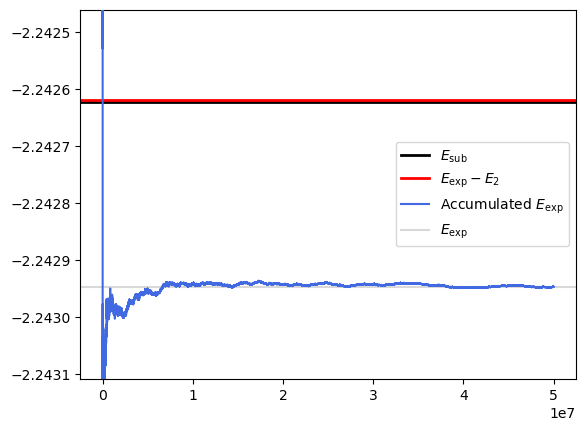

In [13]:
# Main: random example with tunable parameters

#PARAMETERS START____________________________________________________________

dim        = 2
sigma      = 0.05
Hmin, Hmax = -3, 3
Nsamples   = 50000000

#PARAMETERS END______________________________________________________________

H = uniform(Hmin, Hmax, [dim, dim])
H = (H + H.T) / 2

Eigs, Vecs = np.linalg.eigh(H)

Esub  = Eigs[0]
psi0  = Vecs[:,0]

Esub_samples = np.zeros(Nsamples)
corr_samples = np.zeros(Nsamples)

for i in range(Nsamples):
    R = normal(scale=sigma, size=[dim, dim])
    R = (R + R.T) / 2
    S = H + R

    Esub_sample = np.linalg.eigh(S)[0][0]
    corr_sample = sum([np.abs(psi0 @ R @ Vecs[:,k]) ** 2 / (Esub - Eigs[k]) for k in range(1, dim)])

    Esub_samples[i] = Esub_sample
    corr_samples[i] = corr_sample

    if i % 1000 == 0:
        print(i, end='\r')

print("sampling completed")

Eexp_running = np.cumsum(Esub_samples) / np.arange(1, Nsamples + 1)
Eexp         = np.mean(Esub_samples)
corr         = np.mean(corr_samples)

diff                    = Esub - Eexp
diff_corr               = Esub - (Eexp - corr)
remaining_error_percent = 100 * np.abs(diff_corr) / np.abs(diff)

print(f'''
    Error of sample mean           : {Esub - Eexp}
    Error of corrected sample mean : {Esub - (Eexp - corr)}
    Remaining error percent        : {np.round(100 * np.abs(diff_corr) / np.abs(diff), 2)}
''')

plt.figure()
plt.axhline(y=Esub, color='black', label=r'$E_\text{sub}$', linewidth=2)
plt.axhline(y=Eexp - corr, color='red', label=r'$E_\text{exp} - E_2$', linewidth=2)
plt.plot(range(Nsamples), Eexp_running, zorder=10, color='royalblue', label=r'Accumulated $E_\text{exp}$')
plt.axhline(y=Eexp, color='grey', alpha=0.3, zorder=0, label=r'$E_\text{exp}$')
plt.ylim(Eexp - diff/2, Esub + diff/2)
plt.legend()

sampling completed

    Error of sample mean           : 0.042650366636688586
    Error of corrected sample mean : -0.007147722940432522
    Remaining error percent        : 16.76



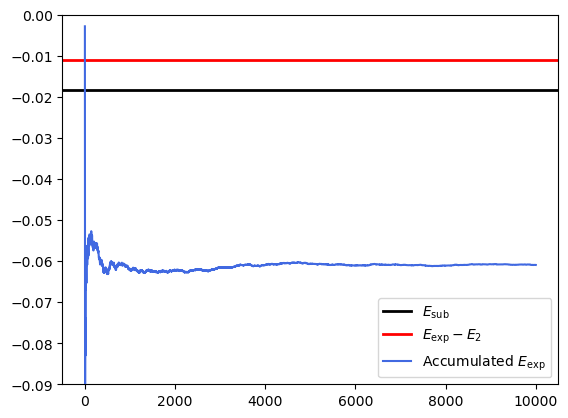

In [3]:
# example 1: fixed example which consistently works and has a strong signal

H = np.array([
    [-0.01, 0.02],
    [0.02, 0.03]
])

Eigs, Vecs = np.linalg.eigh(H)

Esub  = Eigs[0]
E1    = Eigs[1]
psi0  = Vecs[:,0]
psi1  = Vecs[:,1]
gap   = Esub - E1

sigma        = 0.075
Nsamples     = 10000
Esub_samples = np.zeros(Nsamples)
corr_samples = np.zeros(Nsamples)

for i in range(Nsamples):
    R = normal(scale=sigma, size=[2,2])
    R = (R + R.T) / 2
    S = H + R

    Esub_sample = np.linalg.eigh(S)[0][0]
    corr_sample = np.abs(psi0 @ R @ psi1) ** 2 / gap

    Esub_samples[i] = Esub_sample
    corr_samples[i] = corr_sample

    if i % 1000 == 0:
        print(i, end='\r')

print("sampling completed")

Eexp_running = np.cumsum(Esub_samples) / np.arange(1, Nsamples + 1)
Eexp         = np.mean(Esub_samples)
corr         = np.mean(corr_samples)

diff                    = Esub - Eexp
diff_corr               = Esub - (Eexp - corr)
remaining_error_percent = 100 * np.abs(diff_corr) / np.abs(diff)

print(f'''
    Error of sample mean           : {Esub - Eexp}
    Error of corrected sample mean : {Esub - (Eexp - corr)}
    Remaining error percent        : {np.round(100 * np.abs(diff_corr) / np.abs(diff), 2)}
''')

plt.figure()
plt.axhline(y=Esub, color='black', label=r'$E_\text{sub}$', linewidth=2)
plt.axhline(y=Eexp - corr, color='red', label=r'$E_\text{exp} - E_2$', linewidth=2)
plt.plot(range(Nsamples), Eexp_running, zorder=10, color='royalblue', label=r'Accumulated $E_\text{exp}$')
plt.ylim(-0.09, 0.00)
plt.legend()

sampling completed

    Error of sample mean           : 6.905395833825545e-05
    Error of corrected sample mean : -5.651983881249656e-06
    Remaining error percent        : 8.18



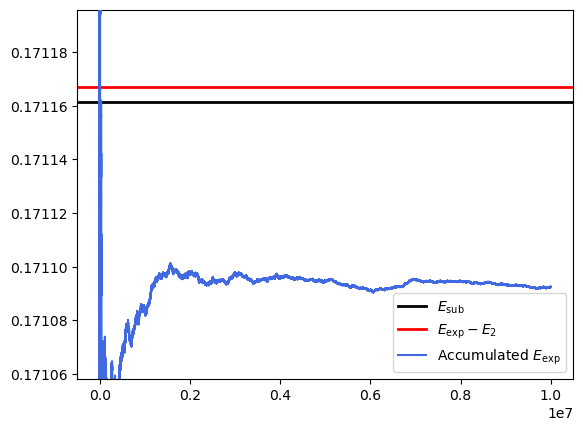

In [27]:
# example 2: random two dimensional example

H = uniform(-1, 1, [2,2])
H = (H + H.T) / 2

Eigs, Vecs = np.linalg.eigh(H)

Esub  = Eigs[0]
E1    = Eigs[1]
psi0  = Vecs[:,0]
psi1  = Vecs[:,1]
gap   = Esub - E1

sigma        = 0.01
Nsamples     = 10000000
Esub_samples = np.zeros(Nsamples)
corr_samples = np.zeros(Nsamples)

for i in range(Nsamples):
    R = normal(scale=sigma, size=[2,2])
    R = (R + R.T) / 2
    S = H + R

    Esub_sample = np.linalg.eigh(S)[0][0]
    corr_sample = np.abs(psi0 @ R @ psi1) ** 2 / gap

    Esub_samples[i] = Esub_sample
    corr_samples[i] = corr_sample

    if i % 1000 == 0:
        print(i, end='\r')

print("sampling completed")

Eexp_running = np.cumsum(Esub_samples) / np.arange(1, Nsamples + 1)
Eexp         = np.mean(Esub_samples)
corr         = np.mean(corr_samples)

diff                    = Esub - Eexp
diff_corr               = Esub - (Eexp - corr)
remaining_error_percent = 100 * np.abs(diff_corr) / np.abs(diff)

print(f'''
    Error of sample mean           : {Esub - Eexp}
    Error of corrected sample mean : {Esub - (Eexp - corr)}
    Remaining error percent        : {np.round(100 * np.abs(diff_corr) / np.abs(diff), 2)}
''')

plt.figure()
plt.axhline(y=Esub, color='black', label=r'$E_\text{sub}$', linewidth=2)
plt.axhline(y=Eexp - corr, color='red', label=r'$E_\text{exp} - E_2$', linewidth=2)
plt.plot(range(Nsamples), Eexp_running, zorder=10, color='royalblue', label=r'Accumulated $E_\text{exp}$')
plt.ylim(Eexp - diff/2, Esub + diff/2)
plt.legend()

sampling completed

    Error of sample mean           : 4.674131683035654e-06
    Error of corrected sample mean : -6.813450788012432e-07
    Remaining error percent        : 14.58



/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


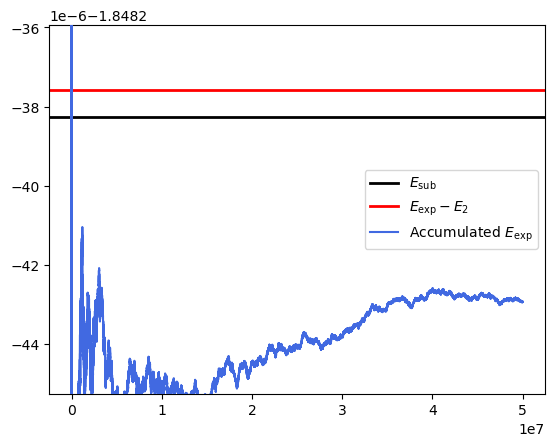

In [ ]:
# example 3: random two dimensional example; larger Hamiltonian, smaller random errors --> more samples needed

H = uniform(-2, 2, [2,2])
H = (H + H.T) / 2

Eigs, Vecs = np.linalg.eigh(H)

Esub  = Eigs[0]
E1    = Eigs[1]
psi0  = Vecs[:,0]
psi1  = Vecs[:,1]
gap   = Esub - E1

sigma        = 0.005
Nsamples     = 50000000
Esub_samples = np.zeros(Nsamples)
corr_samples = np.zeros(Nsamples)

for i in range(Nsamples):
    R = normal(scale=sigma, size=[2,2])
    R = (R + R.T) / 2
    S = H + R

    Esub_sample = np.linalg.eigh(S)[0][0]
    corr_sample = np.abs(psi0 @ R @ psi1) ** 2 / gap

    Esub_samples[i] = Esub_sample
    corr_samples[i] = corr_sample

    if i % 1000 == 0:
        print(i, end='\r')

print("sampling completed")

Eexp_running = np.cumsum(Esub_samples) / np.arange(1, Nsamples + 1)
Eexp         = np.mean(Esub_samples)
corr         = np.mean(corr_samples)

diff                    = Esub - Eexp
diff_corr               = Esub - (Eexp - corr)
remaining_error_percent = 100 * np.abs(diff_corr) / np.abs(diff)

print(f'''
    Error of sample mean           : {Esub - Eexp}
    Error of corrected sample mean : {Esub - (Eexp - corr)}
    Remaining error percent        : {np.round(100 * np.abs(diff_corr) / np.abs(diff), 2)}
''')

plt.figure()
plt.axhline(y=Esub, color='black', label=r'$E_\text{sub}$', linewidth=2)
plt.axhline(y=Eexp - corr, color='red', label=r'$E_\text{exp} - E_2$', linewidth=2)
plt.plot(range(Nsamples), Eexp_running, zorder=10, color='royalblue', label=r'Accumulated $E_\text{exp}$')
plt.ylim(Eexp - diff/2, Esub + diff/2)
plt.legend()